In [ ]:
! pip install langchain langchain-huggingface langchain-community langgraph python-dotenv faiss-cpu pypdf

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [5]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [ ]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [9]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

docs[0]
print(len(docs))

392


In [11]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)
len(chunks)

973

In [ ]:
embeddingModel = embedding = HuggingFaceEmbeddings(model_name = 'sentence-transformers/all-MiniLM-L6-v2')

In [14]:
vectorStore = FAISS.from_documents(chunks, embeddingModel)
vectorStore.index_to_docstore_id

{0: 'c85560d6-59cc-4507-8a4e-a56da094c391',
 1: '585e3f62-e2aa-412b-8a9f-cf655f97e7cf',
 2: '9994b1d6-750f-49d2-a8f4-2ed4e785cc43',
 3: '672dd6a6-550d-46b4-b6b6-214050c027c1',
 4: 'd2c41197-6a6b-490c-a91b-2fbe6868408c',
 5: 'b834c48d-a7ab-4768-855f-640535c9dc70',
 6: '1621378c-2bc9-41b0-a127-202684678163',
 7: 'cf07eddb-a6fb-462e-81e7-bee643ede668',
 8: 'f1a5bd63-a565-4665-a2c8-2f6aac147348',
 9: '6c6ec350-35ce-4fb0-a434-88d4e6701fb2',
 10: '771693b5-3ed6-4812-9243-99c38eab020c',
 11: '3fdcecf0-6921-4100-810d-2a33098b53bb',
 12: '87c7d247-1d77-4852-95d0-ec8644c66e2c',
 13: '9b8158b3-6254-41a7-9d62-1503dbd121fe',
 14: 'db2857cb-4753-4109-98b6-96f662641b57',
 15: 'fdef6b42-491e-4689-824b-d756ced780e6',
 16: '566aeac0-197d-4679-9d35-d4b54f6fcee2',
 17: 'b389ab89-c40b-49f7-9ec3-2e78d491d815',
 18: '5bdd153d-ab2d-48ef-a7f7-42b01354fbb0',
 19: '9ad0daa9-b29d-4333-b461-3994b9ac8a88',
 20: '726bd4af-2e8a-4564-b89e-f986ca1e9311',
 21: '678b32cf-ead6-429e-9461-78f051f21569',
 22: '8b4079eb-575f-

In [16]:
retriever = vectorStore.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [17]:
@tool
def ragPipeline(query: str) -> str:
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [18]:
tools = [ragPipeline]
toolBindedLLM = model.bind_tools(tools)

In [19]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [22]:
def chatNode(state: ChatState):

    messages = state['messages']

    response = toolBindedLLM.invoke(messages)

    return {'messages': [response]}

tool_node = ToolNode(tools)

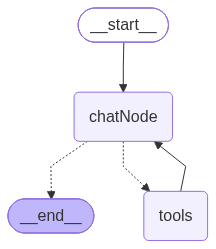

In [24]:
graph = StateGraph(ChatState)

graph.add_node('chatNode', chatNode)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chatNode')
graph.add_conditional_edges('chatNode', tools_condition)
graph.add_edge('tools', 'chatNode')

chatbot = graph.compile()

chatbot

In [25]:
result = chatbot.invoke({"messages": [HumanMessage(content=("Using the pdf notes, explain how to find the ideal value of K in KNN"))]})

In [26]:
print(result['messages'][-1].content)

To find the ideal value of $ K $ in K-Nearest Neighbors (KNN), you can follow a systematic approach involving model evaluation and cross-validation. Here's a step-by-step explanation based on the provided context:

1. **Understand the Role of $ K $**:
   - $ K $ determines how many nearest neighbors are considered when making a prediction. The prediction is based on the majority class among these $ K $ neighbors.
   - A small $ K $ (e.g., $ K = 1 $) makes the model sensitive to noise and outliers, as it relies on a single neighbor.
   - A large $ K $ can smooth out decision boundaries but might lead to over-smoothing and loss of detail.

2. **Evaluate Different Values of $ K $**:
   - Perform predictions using various values of $ K $ (e.g., $ K = 1, 3, 5, 7, 9 $).
   - For each $ K $, compute the model's accuracy on a test dataset (e.g., using `knn.score(X_test, y_test)`).

3. **Use Cross-Validation**:
   - To avoid overfitting and ensure the model generalizes well, use techniques like